In [ ]:
# Forecast Next Quarter
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
from datetime import date, timedelta

In [ ]:
# Aggregate monthly revenue
df = pd.read_csv('clean_retail_data.csv')
df['date'] = pd.to_datetime(df['date'])
monthly = df.groupby(df['date'].dt.to_period('M'))['revenue'].sum().reset_index()
monthly['date'] = monthly['date'].dt.to_timestamp()
monthly['month_num'] = range(len(monthly))

# Simple trend model
X = monthly[['month_num']]
y = monthly['revenue']

model = LinearRegression()
model.fit(X, y)

# Predict next 3 months
future_months = np.array([[len(monthly)], [len(monthly)+1], [len(monthly)+2]])
predictions = model.predict(future_months)

print(f"Next quarter forecast: ${predictions.sum():,.0f}")

Next quarter forecast: $9,186,185


c:\Users\Anumba Ejike John\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Calculate RFM metrics

snapshot_date = df['date'].max()

rfm = df.groupby('customer_id').agg({
    'date': lambda x: (snapshot_date - x.max()).days,  # Recency
    'transaction_id': 'count',                           # Frequency
    'revenue': 'sum'                                     # Monetary
}).rename(columns={'date': 'recency', 'transaction_id': 'frequency', 'revenue': 'monetary'})

# Score 1-5 (quintiles)
rfm['r_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1])  # Lower recency = higher score
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['m_score'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5])

# Combine scores
rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

# Segment
def segment(row):
    if row['r_score'] >= 4 and row['f_score'] >= 4:
        return 'Champions'
    elif row['r_score'] >= 3 and row['f_score'] >= 3:
        return 'Loyal Customers'
    elif row['r_score'] >= 4 and row['f_score'] <= 2:
        return 'New Customers'
    elif row['r_score'] <= 2 and row['f_score'] >= 3:
        return 'At Risk'
    else:
        return 'Lost'

rfm['segment'] = rfm.apply(segment, axis=1)
print(rfm['segment'].value_counts())

C:\Users\Anumba Ejike John\AppData\Local\Temp\ipykernel_7056\3573028871.py:27: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = sales.resample('M')['revenue'].sum().reset_index()


segment
Lost               1316
Loyal Customers    1048
At Risk            1008
Champions           944
New Customers       684
Name: count, dtype: int64


C:\Users\Anumba Ejike John\AppData\Local\Temp\ipykernel_7056\699431166.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = sales.resample('M')['revenue'].sum().reset_index()


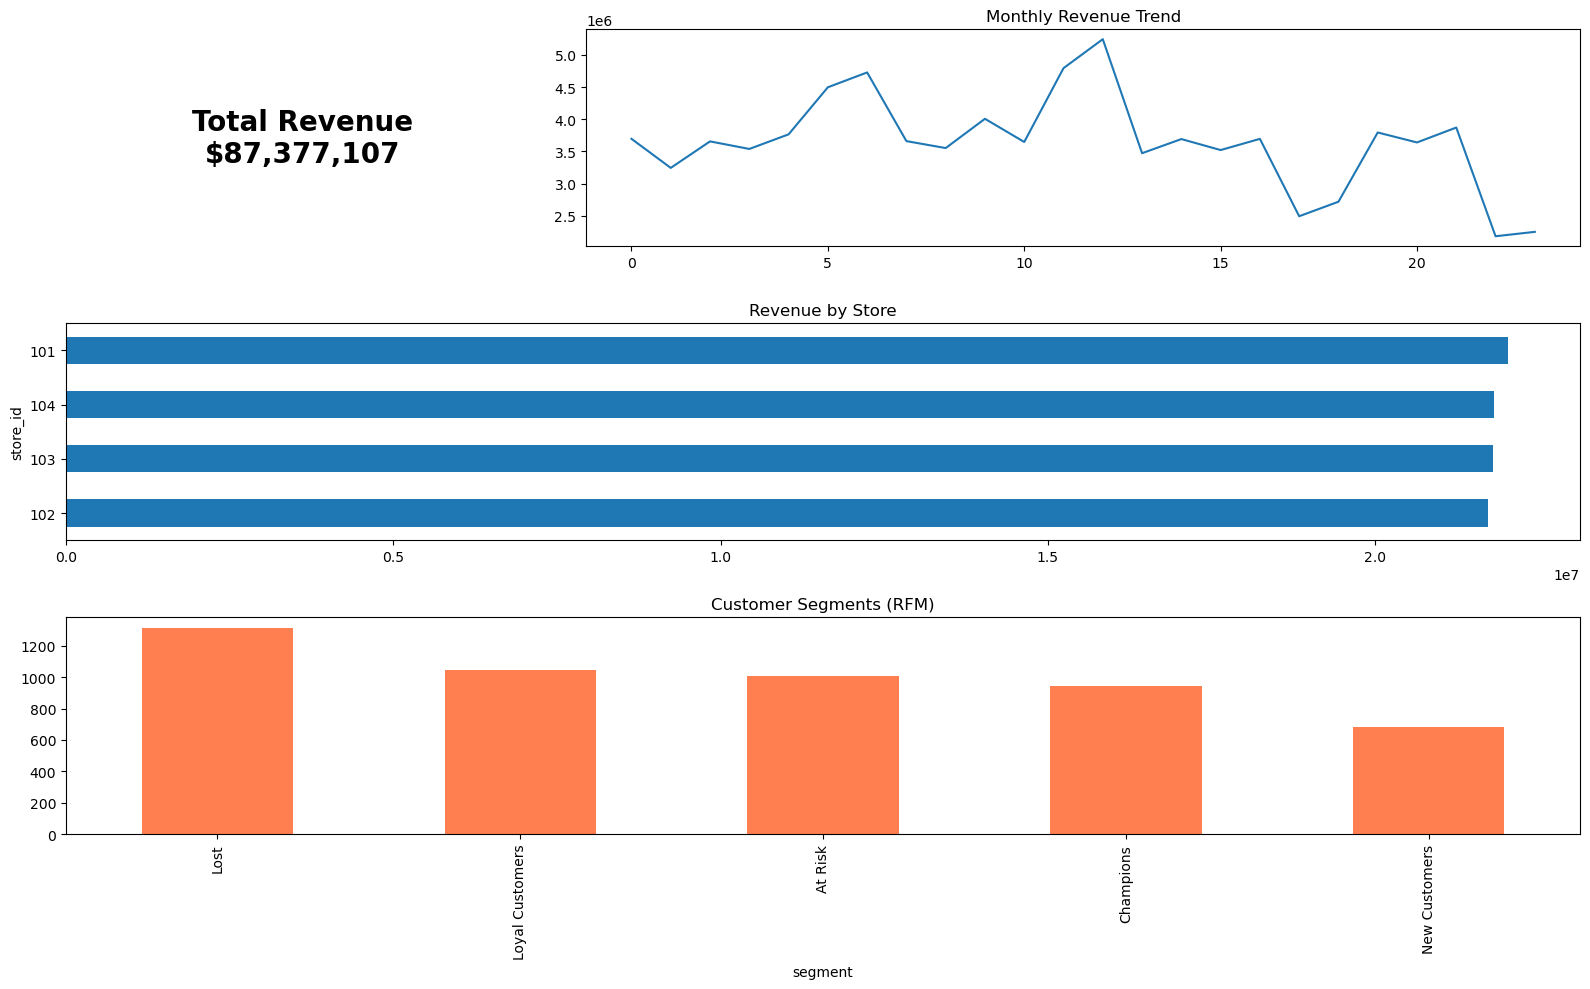

In [24]:
# Phase 3: Executive Dashboard

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Load your cleaned data (from earlier in the notebook)
sales = pd.read_csv('clean_retail_data.csv', parse_dates=['date'])

# ============================================
# CALCULATE KPIs
# ============================================

# 1. Total Revenue
total_revenue = sales['revenue'].sum()

# 2. Total Transactions
total_transactions = len(sales)

# 3. Average Order Value
aov = sales['revenue'].mean()

# 4. Unique Customers
unique_customers = sales['customer_id'].nunique()

# ============================================
# MONTHLY TREND (for trend chart)
# ============================================

sales.set_index('date', inplace=True)
monthly = sales.resample('M')['revenue'].sum().reset_index()

# Need to reload with stores merged, or use the merged dataframe from earlier
# Assuming you have 'clean_retail_data.csv' with region/store info:
df = pd.read_csv('clean_retail_data.csv', parse_dates=['date'])
store_revenue = df.groupby('store_id')['revenue'].sum().sort_values(ascending=True)


fig = plt.figure(figsize=(16, 10))
gs = GridSpec(3, 3, figure=fig)

# KPI cards (text annotations)
ax1 = fig.add_subplot(gs[0, 0])
ax1.text(0.5, 0.5, f'Total Revenue\n${total_revenue:,.0f}', 
         ha='center', va='center', fontsize=20, fontweight='bold')
ax1.axis('off')

# Add more KPIs...

# Trend chart
ax2 = fig.add_subplot(gs[0, 1:])
monthly['revenue'].plot(ax=ax2)
ax2.set_title('Monthly Revenue Trend')

# Store comparison
ax3 = fig.add_subplot(gs[1, :])
store_revenue.plot(kind='barh', ax=ax3)
ax3.set_title('Revenue by Store')

# RFM segments
ax4 = fig.add_subplot(gs[2, :])
rfm['segment'].value_counts().plot(kind='bar', ax=ax4, color='coral')
ax4.set_title('Customer Segments (RFM)')

plt.tight_layout()
plt.savefig('executive_dashboard.png', dpi=300)
plt.show()